In [1]:
import os
from pathlib import Path
import pickle
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from glmhmm import *
from my_fun import fig_size, save_notebook_files

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [3]:
# Plotting style
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'svg'
# %config InlineBackend.figure_format = 'retina'
sns.set_style('ticks')
sns.set_context('notebook')

In [5]:
df = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session=f'glmhmm/TEST/2s_3cov')
df_null = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/1s_null')

# Mean groups 2-4

Kept 20 / 25 subjects after column-wise IQR filtering
Covariate 0: t=11.354, p=0.0000
Covariate 1: t=-1.081, p=0.2932
Covariate 2: t=-8.488, p=0.0000


Text(0.5, 1, '2 states 3 covariates')

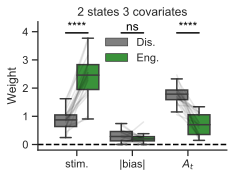

In [5]:
data = results_2_df(df)
figsize = fig_size(n_cols=2)
plot_paired_boxplot_GLMHMM_kernel(data, figsize=figsize, loc='upper center',  bbox_to_anchor=(0.5, 0.95))
plt.title('2 states 3 covariates')

array([[0.98100712, 0.01899288],
       [0.01432419, 0.98567581]])

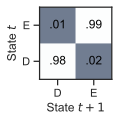

In [44]:
trans_mat = get_str_mat(df, col_name='TransMat')
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
plot_trans_mat(trans_mat, figsize=figsize)

State D occupancy: 0.37
State E occupancy: 0.63


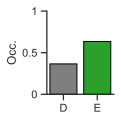

In [45]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
plot_occupancy(df, figsize=figsize)

0.44 ± 0.35 LL (bits/trial)


([], <a list of 0 Text xticklabel objects>)

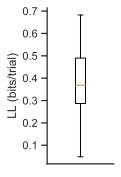

In [20]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[1])
plt.figure(figsize=figsize, constrained_layout=True)
ll_null = df_null.LogLikelihood.unique()
n_trials = df_null.groupby('Subject').size()
ll = df.LogLikelihood.unique()
plot_ll(ll, n_trials, ll_null=ll_null, to_bits=True, figsize=figsize)
plt.xlabel('')
plt.xticks([], [])

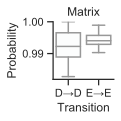

In [46]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
plot_trans_mat_box_plots(trans_mat, figsize=figsize)

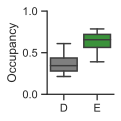

In [48]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
_ = plot_occupancy_boxplot(df, figsize=figsize)

# Group 2

Mice: [325 326 327 329 330 332 333 335 337]
Covariate 0: t=5.941, p=0.0003
Covariate 1: t=-0.912, p=0.3883
Covariate 2: t=-4.740, p=0.0015


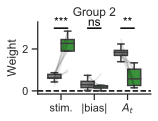

In [6]:
experiment = '2AFC_2'
figsize = fig_size(n_cols=3)
mask = data.Experiment == experiment
print(f'Mice: {data[mask].Animal.unique()}')
title = 'Group ' + experiment[-1]
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Experiment==experiment], title=title, figsize=figsize)
ax.legend_.remove()

# Group 3

Mice: [419 420 422 616 617 619 623]
Covariate 0: t=9.103, p=0.0001
Covariate 1: t=0.335, p=0.7490
Covariate 2: t=-8.737, p=0.0001


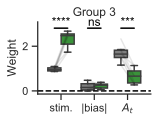

In [7]:
experiment = '2AFC_3'
figsize = fig_size(n_cols=3)
mask = data.Experiment == experiment
print(f'Mice: {data[mask].Animal.unique()}')
title = 'Group ' + experiment[-1]
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Experiment==experiment], title=title, figsize=figsize)
ax.legend_.remove()

# Group 4

Mice: [561 807 820 821]
Covariate 0: t=9.079, p=0.0028
Covariate 1: t=-1.224, p=0.3082
Covariate 2: t=-3.936, p=0.0292


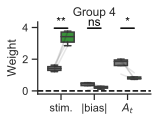

In [8]:
experiment = '2AFC_4'
figsize = fig_size(n_cols=3)
mask = data.Experiment == experiment
print(f'Mice: {data[mask].Animal.unique()}')
title = 'Group ' + experiment[-1]
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Experiment==experiment], title=title, figsize=figsize)
ax.legend_.remove()

# Group 6
Drug

## Rest
No injection (no saline nor drug)

Mice: ['014' '016' '017' '018' '019' '020' '022' '023' '024' '025']
Covariate 0: t=5.223, p=0.0005
Covariate 1: t=-0.189, p=0.8543
Covariate 2: t=-0.923, p=0.3800


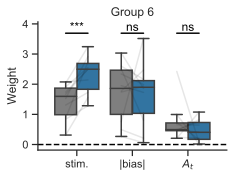

In [218]:
experiment = '2AFC_6'
figsize = fig_size(n_cols=2)
mask = data.Experiment == experiment
print(f'Mice: {data[mask].Animal.unique()}')
title = 'Group ' + experiment[-1]
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Experiment==experiment], title=title, figsize=figsize)
ax.legend_.remove()

array([[0.88030467, 0.11969533],
       [0.09649699, 0.90350301]])

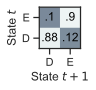

In [219]:
figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
plot_trans_mat(trans_mat[-10:], figsize=figsize)

State 0 occupancy: 0.41
State 1 occupancy: 0.59


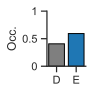

In [220]:
figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
plot_occupancy(posterior_probs[-10:], figsize=figsize)

([<matplotlib.axis.XTick at 0x1ddd9418e88>,
 <a list of 2 Text xticklabel objects>)

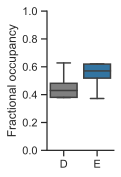

In [221]:
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[1])
_ = plot_occupancy_boxplot(posterior_probs[-10:], figsize=figsize)
plt.xticks([0, 1], ['D', 'E'])

## Saline

In [38]:
# Load results
path = Path.home() / 'PycharmProjects' / 'glmhmm' / 'results_saline.pkl'
with open(path, 'rb') as f:
    results = pickle.load(f)

# Unpack results
all_animals = results['all_animals']
experiment = results['experiment']
fit_ll = results['fit_ll']
weights_saline = results['weights']
trans_mat_saline = results['trans_mat']
posterior_probs_saline = results['posterior_probs']
log_likelihood = results['log_likelihood']
# remap_indices = results['remap_indices']
# interpret = results['interpret']
data_saline = results_2_df(all_animals, experiment, weights_saline)

In [39]:
# Print the number of sessions in results_drug.posterior_probs
for session_probs in results['posterior_probs']:
    print(f' N sessions per subject: {len(session_probs)}')

 N sessions per subject: 7
 N sessions per subject: 9
 N sessions per subject: 10
 N sessions per subject: 5
 N sessions per subject: 4
 N sessions per subject: 11
 N sessions per subject: 10
 N sessions per subject: 9
 N sessions per subject: 9
 N sessions per subject: 9


Covariate 0: t=3.965, p=0.0033
Covariate 1: t=-0.064, p=0.9501
Covariate 2: t=-1.773, p=0.1100


Text(0.5, 1, 'Saline')

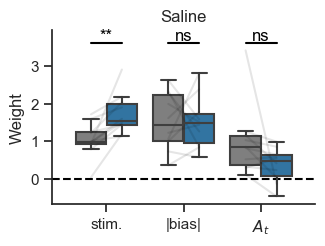

In [40]:
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data_saline, figsize=figsize)
ax.legend_.remove()
plt.title('Saline')

array([[0.89050467, 0.10949533],
       [0.09009037, 0.90990963]])

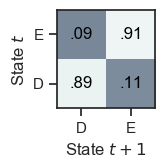

In [41]:
# figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[0]/2)
plot_trans_mat(trans_mat_saline, figsize=figsize)

State 0 occupancy: 0.42
State 1 occupancy: 0.58


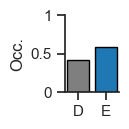

In [42]:
figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
plot_occupancy(posterior_probs_saline, figsize=figsize)

([<matplotlib.axis.XTick at 0x243f7081488>,
 <a list of 2 Text xticklabel objects>)

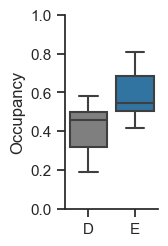

In [43]:
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[1])
df_occ_saline = plot_occupancy_boxplot(posterior_probs_saline, figsize=figsize)
plt.ylabel('Occupancy')
plt.xticks([0, 1], ['D', 'E'])

## Drug

In [30]:
# Load results
path = Path.home() / 'PycharmProjects' / 'glmhmm' / 'results_drug.pkl'
with open(path, 'rb') as f:
    results = pickle.load(f)

# Unpack results
all_animals = results['all_animals']
experiment = results['experiment']
fit_ll = results['fit_ll']
weights_drug = results['weights']
trans_mat_drug = results['trans_mat']
posterior_probs_drug = results['posterior_probs']
log_likelihood = results['log_likelihood']
# remap_indices = results['remap_indices']
# interpret = results['interpret']
data_drug = results_2_df(all_animals, experiment, weights_drug)

In [45]:
# Print the number of sessions in results_drug.posterior_probs
for session_probs in results['posterior_probs']:
    print(f' N sessions per subject: {len(session_probs)}')

 N sessions per subject: 7
 N sessions per subject: 9
 N sessions per subject: 10
 N sessions per subject: 5
 N sessions per subject: 4
 N sessions per subject: 11
 N sessions per subject: 9
 N sessions per subject: 9
 N sessions per subject: 9
 N sessions per subject: 9


Covariate 0: t=7.850, p=0.0000
Covariate 1: t=0.415, p=0.6879
Covariate 2: t=-2.594, p=0.0290


Text(0.5, 1, 'Drug')

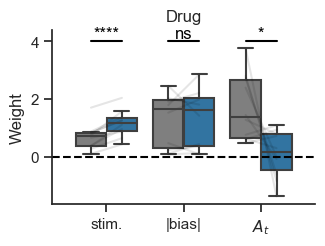

In [46]:
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data_drug, figsize=figsize, palette={0: 'tab:gray', 1: 'tab:blue'}, loc='lower left', bbox_to_anchor=(0, -0.05))
ax.legend_.remove()
plt.title('Drug')

array([[0.91848583, 0.08151417],
       [0.07557074, 0.92442926]])

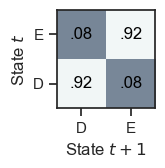

In [47]:
# figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[0]/2)
plot_trans_mat(trans_mat_drug, figsize=figsize)

State 0 occupancy: 0.50
State 1 occupancy: 0.50


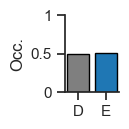

In [48]:
figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
plot_occupancy(posterior_probs_drug, figsize=figsize, color=['tab:gray', 'tab:blue'])

([<matplotlib.axis.XTick at 0x243f7561648>,
 <a list of 2 Text xticklabel objects>)

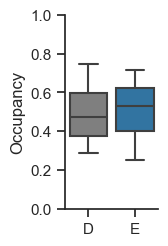

In [49]:
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[1])
df_occ_drug = plot_occupancy_boxplot(posterior_probs_drug, figsize=figsize, palette=['tab:gray', 'tab:blue'])
plt.ylabel('Occupancy')
plt.xticks([0, 1], ['D', 'E'])

## Combine data from states to compare saline vs drug

In [65]:
# Combine saline and drug data DataFrames
data_saline['Drug'] = 0
data_drug['Drug'] = 1
data = pd.concat([data_saline, data_drug], ignore_index=True)

Covariate 0: t=5.399, p=0.0000
Covariate 1: t=0.429, p=0.6725
Covariate 2: t=-4.043, p=0.0007


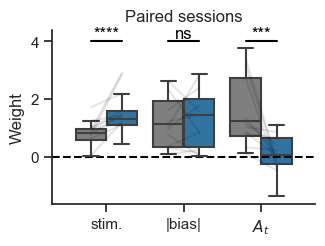

In [109]:
# Combine saline and drug sessions together
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data, drug=False, figsize=figsize, loc='upper left', bbox_to_anchor=(0, 0.995))
plt.title('Paired sessions')
ax.legend_.remove()

t=-1.663, p=0.1307
t=1.663, p=0.1307


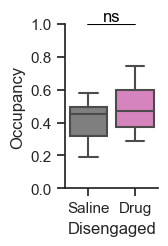

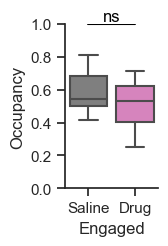

In [110]:
# Combine occupancy dataframes by state. So one df_engaged and one df_disengaged
df_occ_saline['Drug'] = 0
df_occ_drug['Drug'] = 1
df_occ = pd.concat([df_occ_saline, df_occ_drug], ignore_index=True)
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[1])

# Engaged
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(data=df_occ, x='Drug', y='Engaged', palette=['tab:gray','tab:pink'], showfliers=False)
plt.xticks([0,1], ['Saline','Drug'])
plt.ylim(0, 1)
plt.xlabel('Engaged')
plt.ylabel('Occupancy')
sns.despine()
p_saline = df_occ[df_occ.Drug==0]['Engaged']
p_drug = df_occ[df_occ.Drug==1]['Engaged']
t_stat, p_val = ttest_rel(p_saline, p_drug)
print(f't={t_stat:.3f}, p={p_val:.4f}')
add_star_between(p_val)

Mean Disengaged: 0.457 ± 0.032
Mean Engaged: 0.543 ± 0.032


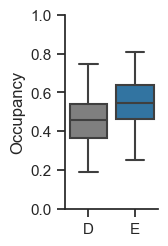

In [111]:
df_occ_melt = df_occ.drop(columns='Drug').melt(id_vars='Subject', var_name='State', value_name='Occupancy')
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[1])
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(data=df_occ_melt, x='State', y='Occupancy', palette=['tab:gray','tab:blue'], showfliers=False)
plt.xticks([0,1], ['D','E'])
plt.ylim(0, 1)
plt.xlabel('')
plt.ylabel('Occupancy')
sns.despine()
p_disengaged = df_occ.Disengaged
print(f'Mean Disengaged: {p_disengaged.mean():.3f} ± {p_disengaged.sem():.3f}')
p_engaged = df_occ.Engaged
print(f'Mean Engaged: {p_engaged.mean():.3f} ± {p_engaged.sem():.3f}')

array([[0.90449525, 0.09550475],
       [0.08283056, 0.91716944]])

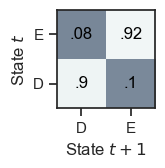

In [112]:
trans_mat_saline = plot_trans_mat(trans_mat_saline)
plt.close()
trans_mat_drug = plot_trans_mat(trans_mat_drug)
plt.close()
trans_mat = np.mean([trans_mat_saline, trans_mat_drug], axis=0)
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[0]/2)
plot_trans_mat(trans_mat, figsize=figsize)

## Disengaged

Covariate 0: t=-1.398, p=0.1956
Covariate 1: t=0.324, p=0.7534
Covariate 2: t=0.483, p=0.6404


Text(0.5, 1, 'Disengaged')

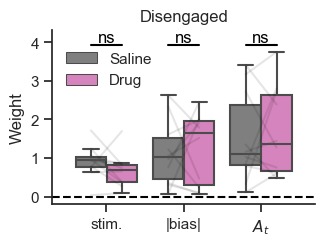

In [113]:
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Label=='Disengaged'], drug=True, figsize=figsize, loc='upper left', bbox_to_anchor=(0, 0.95))
plt.title('Disengaged')

Covariate 0: t=-0.473, p=0.6473
Covariate 1: t=2.064, p=0.0690
Covariate 2: t=-1.310, p=0.2228


Text(0.5, 1, 'Disengaged')

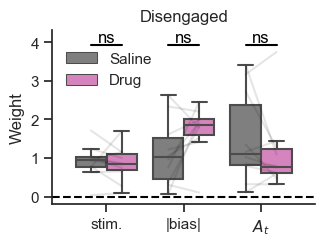

In [132]:
# Run 1
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Label=='Disengaged'], drug=True, figsize=figsize, loc='upper left', bbox_to_anchor=(0, 0.95))
plt.title('Disengaged')

## Engaged

Covariate 0: t=-3.415, p=0.0077
Covariate 1: t=0.380, p=0.7129
Covariate 2: t=-0.051, p=0.9603


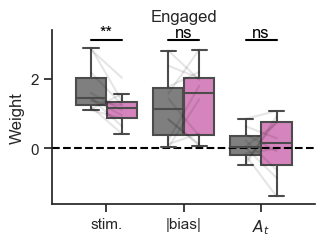

In [115]:
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Label=='Engaged'], drug=True, figsize=figsize)
plt.title('Engaged')
ax.get_legend().remove()

Covariate 0: t=-2.526, p=0.0324
Covariate 1: t=2.621, p=0.0278
Covariate 2: t=1.538, p=0.1584


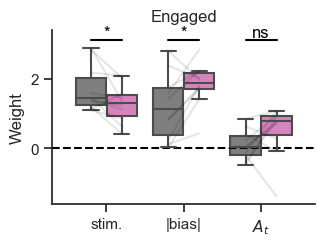

In [133]:
# Run 1
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Label=='Engaged'], drug=True, figsize=figsize)
plt.title('Engaged')
ax.get_legend().remove()

# Test df output

In [19]:
from glue_sessions import glue_animals
from glmhmm import *
import numpy as np

## Saline

In [23]:
experiment = '2AFC_6'
df = glue_animals(experiment=experiment, path_session=f'glmhmm/2s_2cov/saline', filter_drug=False, update=False, to_csv=False)  # GLM HMM fits
df.Subject = df.Subject.astype(str)
df['Subject'] = df['Subject'].str.zfill(3)

n_states = df.Nstates.unique()[0]
obs_dim = df.ObservedDimensions.unique()[0]
input_dim = df.InputDimensions.unique()[0]

weights_saline = [np.fromstring(s.strip('[]'), sep=' ').reshape(n_states, obs_dim, input_dim) for s in df.Weights.unique()]
trans_mat = [np.fromstring(s.strip('[]'), sep=' ').reshape(n_states, n_states) for s in df.TransMat.unique()]
all_animals = df.Subject.unique()
experiment = [experiment] * len(all_animals)

data_saline = results_2_df(all_animals, experiment, weights_saline)

([<matplotlib.axis.XTick at 0x29285ef6e48>,
 <a list of 2 Text xticklabel objects>)

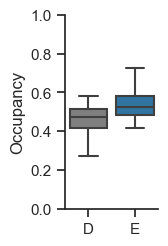

In [24]:
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[1])
df_occ_saline = plot_occupancy_boxplot(df, figsize=figsize, palette=['tab:gray', 'tab:blue'])
plt.ylabel('Occupancy')
plt.xticks([0, 1], ['D', 'E'])

# Drug

In [25]:
experiment = '2AFC_6'
df = glue_animals(experiment=experiment, path_session='glmhmm/2s_2cov/drug', filter_drug=False, update=False, to_csv=False)  # GLM HMM fits
df.Subject = df.Subject.astype(str)
df['Subject'] = df['Subject'].str.zfill(3)

n_states = df.Nstates.unique()[0]
obs_dim = df.ObservedDimensions.unique()[0]
input_dim = df.InputDimensions.unique()[0]

weights_drug = [np.fromstring(s.strip('[]'), sep=' ').reshape(n_states, obs_dim, input_dim) for s in df.Weights.unique()]
trans_mat = [np.fromstring(s.strip('[]'), sep=' ').reshape(n_states, n_states) for s in df.TransMat.unique()]
all_animals = df.Subject.unique()
experiment = [experiment] * len(all_animals)

data_drug = results_2_df(all_animals, experiment, weights_drug)

([<matplotlib.axis.XTick at 0x292869e3348>,
 <a list of 2 Text xticklabel objects>)

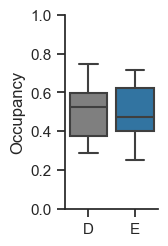

In [26]:
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[1])
df_occ_saline = plot_occupancy_boxplot(df, figsize=figsize, palette=['tab:gray', 'tab:blue'])
plt.ylabel('Occupancy')
plt.xticks([0, 1], ['D', 'E'])

In [27]:
# Combine saline and drug data DataFrames
data_saline['Drug'] = 0
data_drug['Drug'] = 1
data = pd.concat([data_saline, data_drug], ignore_index=True)

t=-1.131, p=0.2874


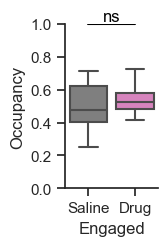

In [31]:
# Combine occupancy dataframes by state. So one df_engaged and one df_disengaged
df_occ_saline['Drug'] = 0
df_occ_drug['Drug'] = 1
df_occ = pd.concat([df_occ_saline, df_occ_drug], ignore_index=True)
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[1])

# Engaged
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(data=df_occ, x='Drug', y='Engaged', palette=['tab:gray','tab:pink'], showfliers=False)
plt.xticks([0,1], ['Saline','Drug'])
plt.ylim(0, 1)
plt.xlabel('Engaged')
plt.ylabel('Occupancy')
sns.despine()
p_saline = df_occ[df_occ.Drug==0]['Engaged']
p_drug = df_occ[df_occ.Drug==1]['Engaged']
t_stat, p_val = ttest_rel(p_saline, p_drug)
print(f't={t_stat:.3f}, p={p_val:.4f}')
add_star_between(p_val)

# Save all notebook's figures

In [30]:
# # Whole notebook outputs (no input or prompt, only Markdown and figures)
# # As HTML
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# # As PDF
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt
#
# Export all figures
# save_notebook_files(notebook_path='notebook_full_model.ipynb')